In [ ]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Enter_your_password",
    database="ecommerce",
    auth_plugin='mysql_native_password'    
)

query = "SELECT * FROM detailed_order_analysis"
df = pd.read_sql(query, conn)

print(df.info())

df.to_csv('detailed_order_analysis.csv', index=False)

print("Export complete! File saved as 'detailed_order_analysis.csv'")

C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\2844894892.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108457 entries, 0 to 108456
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  108457 non-null  object        
 1   customer_id               108457 non-null  object        
 2   customer_state            108457 non-null  object        
 3   customer_city             108457 non-null  object        
 4   order_status              108457 non-null  object        
 5   order_purchase_timestamp  108457 non-null  datetime64[ns]
 6   delivery_vs_estimated     108449 non-null  float64       
 7   actual_delivery_days      108449 non-null  float64       
 8   price                     108457 non-null  float64       
 9   freight_value             108457 non-null  float64       
 10  product_id                108457 non-null  object        
 11  category                  108457 non-null  object        
 12  sc

In [2]:
# Group by state and sum the price
state_sales = df.groupby('customer_state')['price'].sum().sort_values(ascending=False).reset_index()

print(state_sales.head())

  customer_state       price
0             SP  5001292.29
1             RJ  1718451.15
2             MG  1526703.06
3             RS   720778.46
4             PR   658634.77


C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\2710603977.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, 'SP'),
  Text(1, 0, 'RJ'),
  Text(2, 0, 'MG'),
  Text(3, 0, 'RS'),
  Text(4, 0, 'PR'),
  Text(5, 0, 'SC'),
  Text(6, 0, 'BA'),
  Text(7, 0, 'DF'),
  Text(8, 0, 'GO'),
  Text(9, 0, 'ES'),
  Text(10, 0, 'PE'),
  Text(11, 0, 'CE'),
  Text(12, 0, 'PA'),
  Text(13, 0, 'MT'),
  Text(14, 0, 'MS'),
  Text(15, 0, 'MA'),
  Text(16, 0, 'PB'),
  Text(17, 0, 'PI'),
  Text(18, 0, 'RN'),
  Text(19, 0, 'AL'),
  Text(20, 0, 'SE'),
  Text(21, 0, 'TO'),
  Text(22, 0, 'RO'),
  Text(23, 0, 'AM'),
  Text(24, 0, 'AC'),
  Text(25, 0, 'AP'),
  Text(26, 0, 'RR')])

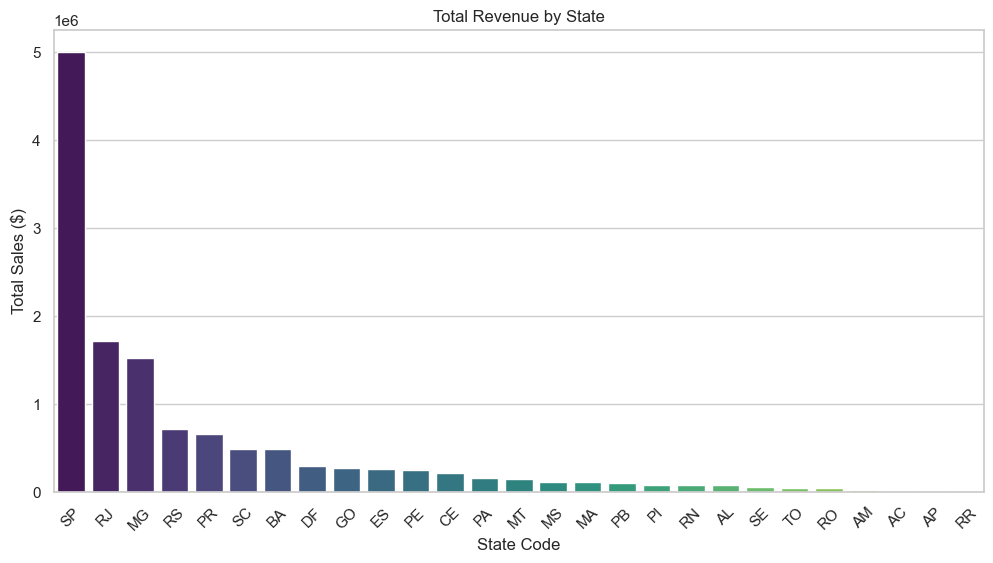

In [ ]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6)) 

sns.barplot(
    data=state_sales, 
    x='customer_state', 
    y='price', 
    palette='viridis' 
)

plt.title('Total Revenue by State')
plt.xlabel('State Code')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45) # Tilts labels so they don't overlap




Sao Paulo drives the highest sales and rest of the states are lacking.

In [4]:
sp_data = df[df['customer_state'] == 'SP']
city_sales_sp = sp_data.groupby('customer_city')['price'].sum().sort_values(ascending=False).reset_index()

print(city_sales_sp.head(10))

           customer_city       price
0              sao paulo  1833181.12
1               campinas   183010.71
2              guarulhos   136015.95
3  sao bernardo do campo   100790.75
4                 santos    95973.36
5            santo andre    88841.46
6                 osasco    80294.94
7                jundiai    78627.41
8    sao jose dos campos    74584.74
9               sorocaba    73905.03


C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\3574307098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


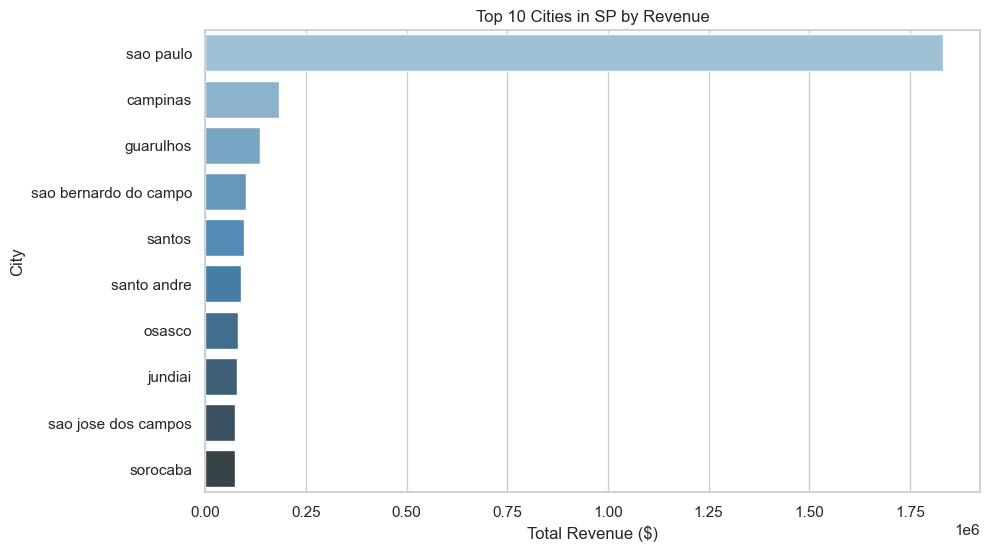

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=city_sales_sp.head(10), 
    y='customer_city', 
    x='price', 
    palette='Blues_d'
)
plt.title('Top 10 Cities in SP by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('City')
plt.show()

Tourism driving sales in the capital or maybe high population density in the capital. low viability in other cities.

Logistics Comparison within SP:
     location_type  freight_value  actual_delivery_days
0     Capital (SP)      14.302335              7.970961
1  Other SP Cities      15.640615              9.059882


C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\1684109206.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sp_data['location_type'] = sp_data['customer_city'].apply(
C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\1684109206.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_logistics, x='customer_state', y='freight_value', palette='viridis')


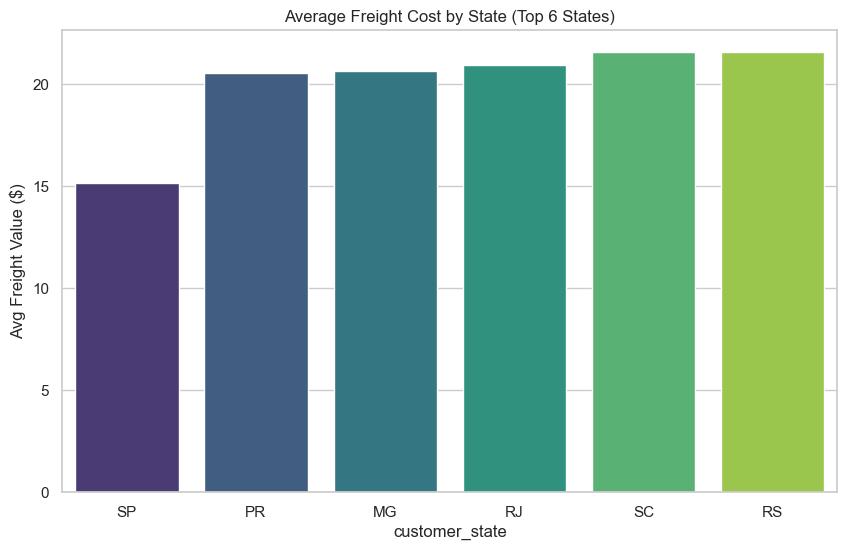

In [ ]:
# Analysis: Freight Advantage (Capital vs Other)
sp_data['location_type'] = sp_data['customer_city'].apply(
    lambda x: 'Capital (SP)' if x == 'sao paulo' else 'Other SP Cities'
)

freight_comp = sp_data.groupby('location_type').agg({
    'freight_value': 'mean',
    'actual_delivery_days': 'mean'
}).reset_index()

print("Logistics Comparison within SP:")
print(freight_comp)

# Analysis: SP vs Other Top States
top_6_states = df.groupby('customer_state')['price'].sum().nlargest(6).index
state_logistics = df[df['customer_state'].isin(top_6_states)].groupby('customer_state').agg({
    'freight_value': 'mean',
    'actual_delivery_days': 'mean'
}).sort_values('freight_value').reset_index()

# Plotting the Freight Gap
plt.figure(figsize=(10, 6))
sns.barplot(data=state_logistics, x='customer_state', y='freight_value', palette='viridis')
plt.title('Average Freight Cost by State (Top 6 States)')
plt.ylabel('Avg Freight Value ($)')
plt.show()

Lower freight values in sao paulo seems to be a contributing factor to higher sales.

In [7]:
# We sum 'price' for total sales and count 'order_id' for quantity
product_sales = df.groupby(['product_id', 'category']).agg({
    'price': 'sum',
    'order_id': 'count'
}).reset_index()

product_sales.columns = ['Product ID', 'Category', 'Total Revenue', 'Units Sold']

top_products = product_sales.sort_values(by='Total Revenue', ascending=False)

print(top_products.head(10))

                             Product ID                 Category  \
23016  bb50f2e236e5eea0100680137654686c          health_beauty\r   
13429  6cdd53843498f92890544667809f1595          health_beauty\r   
26395  d6160fb7873f184099d9bc95e30376af              computers\r   
25842  d1c427060a0f73f6b889a5c7c61f2ac4  computers_accessories\r   
18858  99a4788cb24856965c36a24e339b6058         bed_bath_table\r   
7695   3dd2a17168ec895c781a9191c1e95ad7  computers_accessories\r   
4778   25c38557cf793876c5abdd5931f922db                   baby\r   
11793  5f504b3a1c75b73d6151be81eb05bdc9             cool_stuff\r   
10367  53b36df67ebb7c41585e8d54d6772e08          watches_gifts\r   
21139  aca2eb7d00ea1a7b8ebd4e68314663af        furniture_decor\r   

       Total Revenue  Units Sold  
23016       63885.00         195  
13429       53302.40         152  
26395       45949.35          33  
25842       45322.56         330  
18858       41597.16         472  
7695        40632.90         271  
4778  

Top 10 Categories by Revenue:
                   Category  Total Revenue  Units Sold
43          health_beauty\r     1228986.81        9456
70          watches_gifts\r     1160289.57        5825
7          bed_bath_table\r     1027333.65       10985
65         sports_leisure\r      954296.99        8436
15  computers_accessories\r      892279.63        7672
39        furniture_decor\r      712414.53        8159
49             housewares\r      613843.72        6780
20             cool_stuff\r      605088.81        3698
5                    auto\r      572750.14        4117
42           garden_tools\r      468477.18        4254


C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\1323472072.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='Total Revenue', y='Category', palette='rocket')
) missing from font(s) Arial.g\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


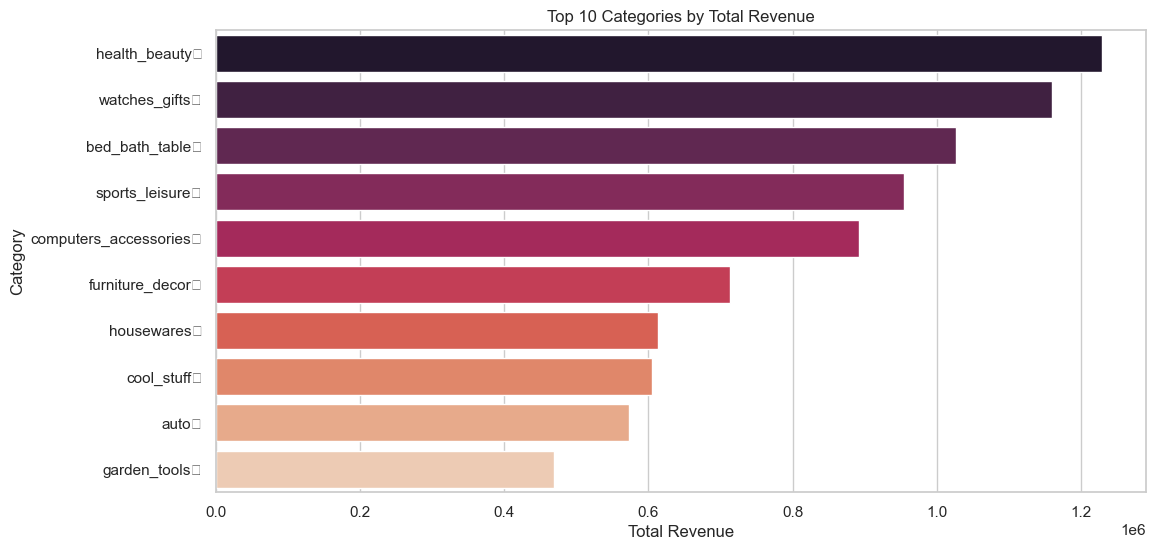

In [8]:
category_performance = df.groupby('category').agg({
    'price': 'sum',
    'order_id': 'count'
}).reset_index()

category_performance.columns = ['Category', 'Total Revenue', 'Units Sold']

top_categories = category_performance.sort_values(by='Total Revenue', ascending=False).head(10)

print("Top 10 Categories by Revenue:")
print(top_categories)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='Total Revenue', y='Category', palette='rocket')
plt.title('Top 10 Categories by Total Revenue')
plt.show()

Self care products have the dominant shares in sales.

                      Category  Total Revenue  Units Sold
0        security_and_services         283.29           2
1  fashion_childrens_clothes\r         519.95           7
2             home_comfort_2\r         721.57          27
3          cds_dvds_musicals\r         730.00          14
4                    flowers\r        1000.24          31
5        diapers_and_hygiene\r        1500.79          37
6      arts_and_craftmanship\r        1814.01          24
7                 la_cuisine\r        1917.99          13
8              fashion_sport\r        2119.51          30
9     fashio_female_clothing\r        2700.84          46


C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\4195563995.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_categories.head(10), x='Total Revenue', y='Category', palette='mako')
) missing from font(s) Arial.g\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


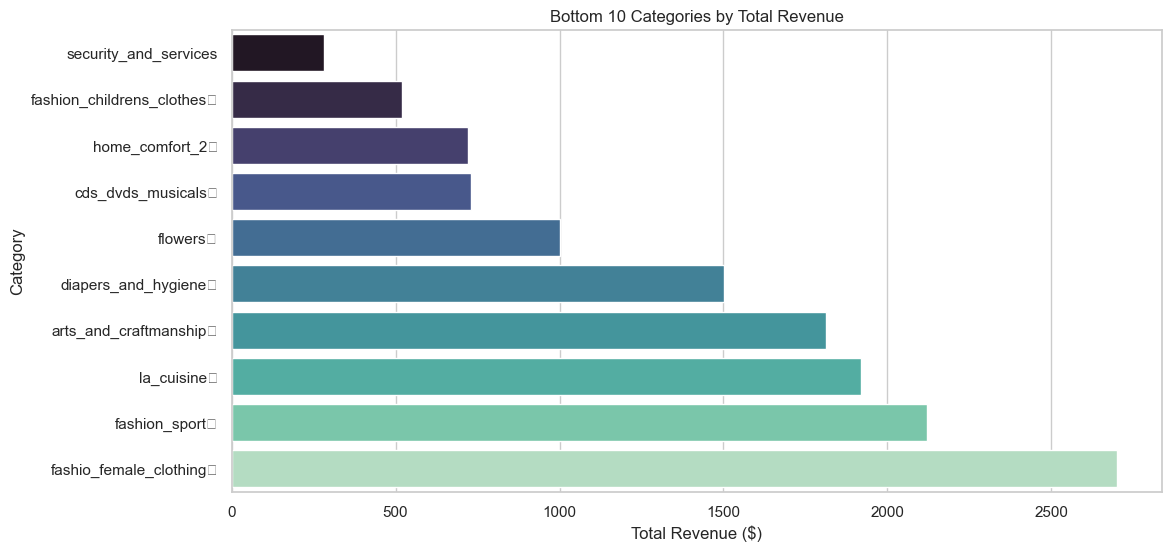

In [9]:
worst_categories = df.groupby('category').agg({
    'price': 'sum',
    'order_id': 'count'
}).sort_values(by='price', ascending=True).reset_index()

worst_categories.columns = ['Category', 'Total Revenue', 'Units Sold']

print(worst_categories.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=worst_categories.head(10), x='Total Revenue', y='Category', palette='mako')
plt.title('Bottom 10 Categories by Total Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Category')
plt.show()

Too many Weak categories with security_and_Services having sales extremely low (just 2 products sold). Why?

In [10]:
worst_10_cats = df.groupby('category')['price'].sum().nsmallest(10).index

worst_analysis = df[df['category'].isin(worst_10_cats)].groupby('category').agg({
    'price': 'mean',
    'freight_value': 'mean',
    'order_id': 'count'
}).reset_index()

worst_analysis['freight_ratio'] = worst_analysis['freight_value'] / worst_analysis['price']

worst_analysis = worst_analysis.sort_values('price')
print(worst_analysis)

                      category       price  freight_value  order_id  \
7             home_comfort_2\r   26.724815      13.518889        27   
6                    flowers\r   32.265806      14.630645        31   
2        diapers_and_hygiene\r   40.561892      14.740541        37   
1          cds_dvds_musicals\r   52.142857      16.070714        14   
3     fashio_female_clothing\r   58.713913      12.963043        46   
5              fashion_sport\r   70.650333      19.237667        30   
4  fashion_childrens_clothes\r   74.278571      11.245714         7   
0      arts_and_craftmanship\r   75.583750      15.422083        24   
9        security_and_services  141.645000      20.610000         2   
8                 la_cuisine\r  147.537692      25.649231        13   

   freight_ratio  
7       0.505855  
6       0.453441  
2       0.363409  
1       0.308205  
3       0.220783  
5       0.272294  
4       0.151399  
0       0.204040  
9       0.145505  
8       0.173849  


home_comfort_2, flowers, diapers_and_hygiene, cds_dvds_musicals likely have low sales due to high shipping costs most people would cancel their order or abandon the cart the moment they see shipping constitutes around 30% or more of their bill.

C:\Users\abh02\AppData\Local\Temp\ipykernel_9232\4190748502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=slowest_delivery, x='actual_delivery_days', y='category', palette='coolwarm')


Top 10 Slowest Categories (Avg Delivery Days):
                               category  actual_delivery_days  \
57                   office_furniture\r             20.775841   
31                      fashion_shoes\r             15.437500   
61                security_and_services             15.000000   
46                     home_comfort_2\r             14.925926   
12                 christmas_supplies\r             14.475524   
41  furniture_mattress_and_upholstery\r             14.405405   
40              furniture_living_room\r             13.797571   
45                  home_appliances_2\r             13.797414   
42                       garden_tools\r             13.589093   
33            fashion_underwear_beach\r             13.555556   

    delivery_vs_estimated  
57             -11.825721  
31             -14.816406  
61             -17.000000  
46              -7.925926  
12             -12.811189  
41              -7.162162  
40             -11.825911  
45           

) missing from font(s) Arial.g\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


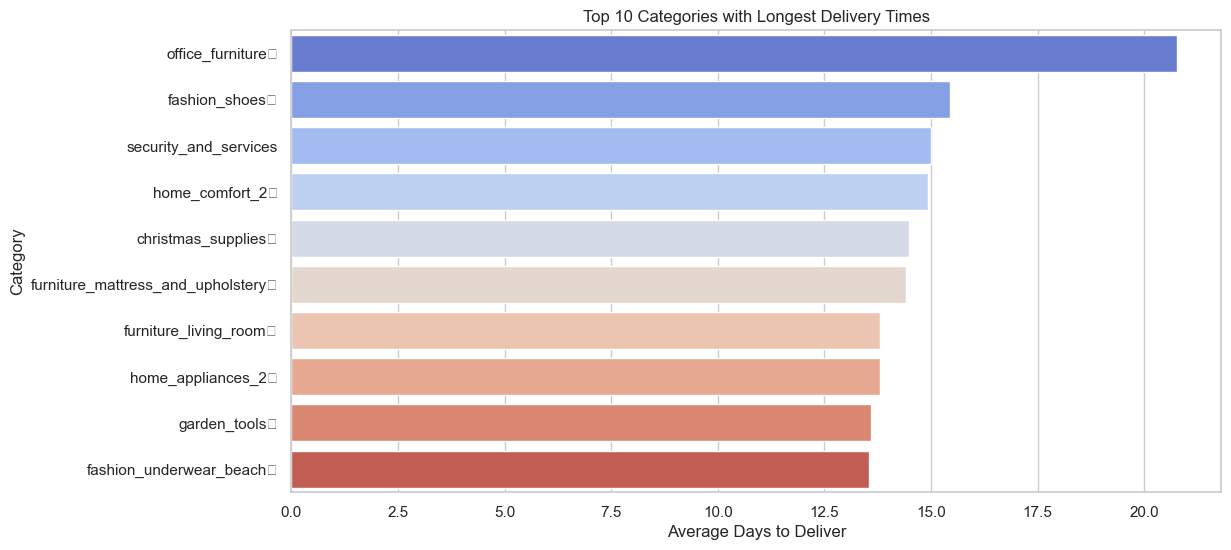

In [11]:
delivery_stats = df.groupby('category').agg({
    'actual_delivery_days': 'mean',
    'delivery_vs_estimated': 'mean'
}).reset_index()

slowest_delivery = delivery_stats.sort_values(by='actual_delivery_days', ascending=False).head(10)

print("Top 10 Slowest Categories (Avg Delivery Days):")
print(slowest_delivery)

plt.figure(figsize=(12, 6))
sns.barplot(data=slowest_delivery, x='actual_delivery_days', y='category', palette='coolwarm')

plt.title('Top 10 Categories with Longest Delivery Times')
plt.xlabel('Average Days to Deliver')
plt.ylabel('Category')
plt.show()

Security and services also have one of the worst deliveries. Should be worked on if the company wants to expand in that category otherwise a complete shutdown of that category to cut losses is the more viable option.

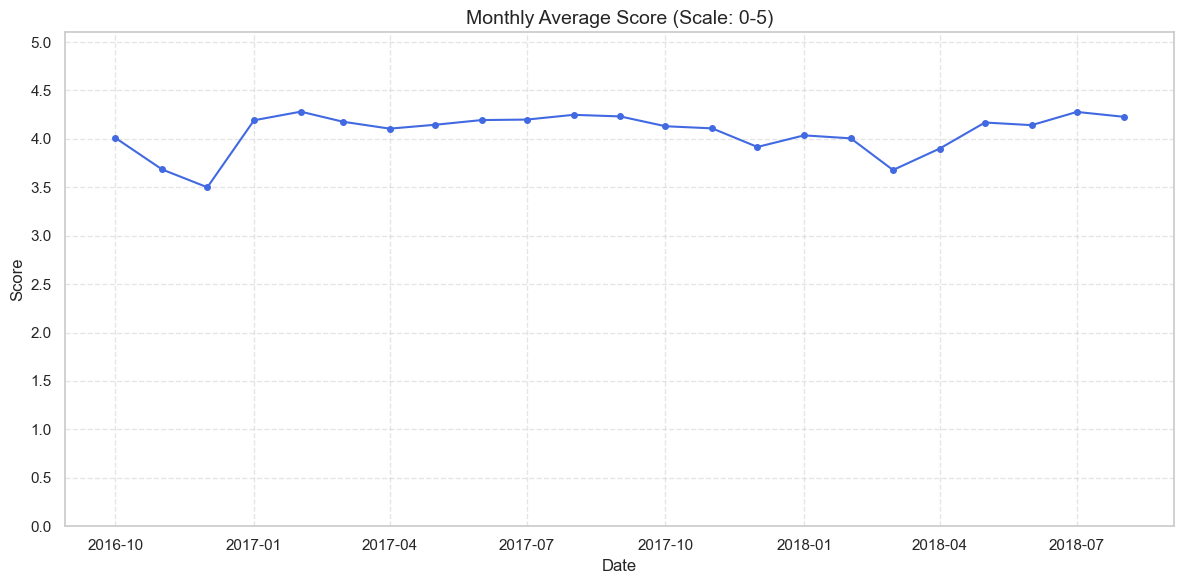

In [ ]:
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
monthly_trend = df.resample('MS', on='review_creation_date')['score'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend['review_creation_date'], monthly_trend['score'], 
         marker='o', markersize=4, linestyle='-', color='royalblue')


plt.ylim(0, 5.1) 

plt.yticks(np.arange(0, 5.5, 0.5)) 

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.title('Monthly Average Score (Scale: 0-5)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Score')

plt.tight_layout()
plt.show()

Overall reviews looks good however during late 2016 and early 2018 the avg reviews fell below 4.00

In [13]:
avg_score_by_category= df.groupby('category')['score'].mean().reset_index()

worst_reviews = avg_score_by_category.sort_values('score', ascending=False).tail(10)

print(worst_reviews)

plt.Figure(figsize=(12,6))

                               category     score
41  furniture_mattress_and_upholstery\r  3.891892
47                       home_confort\r  3.851163
58                     party_supplies\r  3.833333
4                               audio\r  3.830084
34                    fixed_telephony\r  3.758893
30              fashion_male_clothing\r  3.758065
46                     home_comfort_2\r  3.629630
57                   office_furniture\r  3.517428
23                diapers_and_hygiene\r  3.378378
61                security_and_services  2.500000


<Figure size 1200x600 with 0 Axes>

) missing from font(s) Arial.Temp\ipykernel_9232\1859667081.py:19: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) Arial.g\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


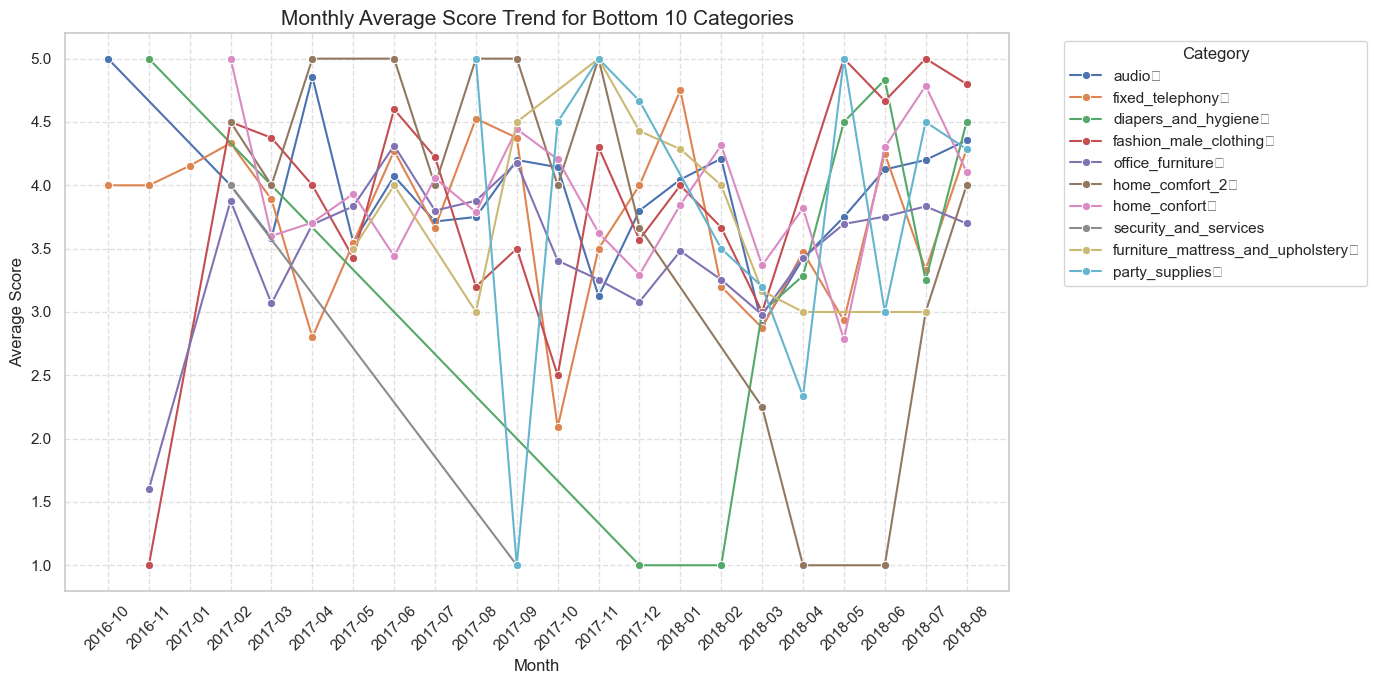

In [14]:
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])

df['month'] = df['review_creation_date'].dt.to_period('M').astype(str)

worst_category_names = worst_reviews['category'].tolist()

monthly_worst = df[df['category'].isin(worst_category_names)]
monthly_data = monthly_worst.groupby(['month', 'category'])['score'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_data, x='month', y='score', hue='category', marker='o')

plt.title('Monthly Average Score Trend for Bottom 10 Categories', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=45) # Rotate labels so they don't overlap
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The drop in avg review in late 2016 seems to be because of bad reviews in fashion_male_clothing and office_furniture that was resolved.

Later the drop in early 2018 seems to be because of extremely negative reviews in diapers_and_hygeine and home_comfort_2 both of which went from absolute bottom to a 4.0+ and 4.0 avg review respectively. Checking what was changed during that time might lead to more insights. (cannot generate insights for that due to data constraints)